# Quickstart: ropls-compatible OPLS-DA

This notebook demonstrates the `pi-oplsda` workflow configured to match R `ropls` as closely as possible. The model uses `compatibility="ropls"` and `n_ortho="auto"`, so the orthogonal component count is selected with the ropls-style component rule and Q2 calculation. This is the recommended quickstart when you want to compare Python outputs with ropls visualizations.


In [1]:
import numpy as np
import pandas as pd

import piopls
from piopls import OPLSDA, OPLSDA_Visualizer

print(f"pi-oplsda version: {piopls.__version__}")


pi-oplsda version: 1.1.0


## 1. Load the sacurine example data

The example uses pandas objects so sample and feature names are retained in exported tables.


In [2]:
df_X = pd.read_csv("../src/piopls/data/sacurine_X.csv", index_col=0)
df_Y = pd.read_csv("../src/piopls/data/sacurine_Y.csv", index_col=0)
y = df_Y.iloc[:, 0]

print("X shape:", df_X.shape)
display(y.value_counts().rename("n"))


X shape: (183, 109)


Gender
M    100
F     83
Name: n, dtype: int64

## 2. Fit in ropls-compatible auto mode

`n_ortho="auto"` searches the orthogonal component count up to `max_ortho`. In `compatibility="ropls"` mode, `cv_strategy="auto"`, `selection_rule="auto"`, `rmsee_correction="auto"`, and `pvalue_method="auto"` all resolve to ropls-compatible behavior.


In [3]:
model = OPLSDA(
    n_ortho="auto",
    max_ortho=10,
    cv_folds=7,
    compatibility="ropls",
    scale="standard",
    random_state=42,
    n_perms=100,
    n_jobs=-1,
)

model.fit_pipeline(df_X, y, run_permutations=False)

print(f"Selected orthogonal components: {model.n_ortho_}")
display(model.get_model_info_df())
display(model.get_summary_df())


Selected orthogonal components: 2


,N_Predictive,N_Ortho,R2X(cum),R2Y(cum),Q2(cum),RMSEE,Compatibility,CV_Strategy
0,1,2,0.275229,0.729833,0.60153,0.261639,ropls,ropls_venetian


,Component,R2X,R2Y,Q2,R2X(cum),R2Y(cum),Q2(cum)
0,Predictive (p1),0.049934,0.479107,0.401051,0.049934,0.479107,0.401051
1,Orthogonal (o1),0.125893,0.189217,0.152912,0.175827,0.189217,0.152912
2,Orthogonal (o2),0.099402,0.061509,0.047567,0.275229,0.250726,0.200480


## 3. Inspect scores and feature importance

These tables use the same naming convention expected by the diagnostic visualizer and are intended to be easy to compare with ropls outputs.


In [4]:
scores_df = model.get_scores_df(y_true=y)
features_df = model.get_features_df(feature_names=df_X.columns)

display(scores_df.head())
display(features_df.head(10))


,Sample,t_pred (p1),t_ortho (o1),t_ortho (o2),True_Class,Fitted_Value,Fitted_Class,Match_Status
0,HU_011,1.582933,4.980604,-5.268184,M,0.841541,M,Matched
1,HU_014,-1.372806,1.744338,-0.892428,F,0.290528,F,Matched
2,HU_015,3.341370,3.437277,-2.477440,M,1.169351,M,Matched
3,HU_017,3.590063,0.979496,-3.557066,M,1.215713,M,Matched
4,HU_018,1.662716,-0.315585,3.628218,M,0.856414,M,Matched


,Feature,VIP,Covariance (p1),Correlation (pcorr1),Loading_Weight
0,p-Anisic acid,2.533220,-1.393154,-0.566073,-0.247445
1,Malic acid,2.479289,-0.320155,-0.554021,-0.242177
2,Testosterone glucuronide,2.421591,0.720792,0.541128,0.236541
3,Pantothenic acid,2.165296,-0.282849,-0.483856,-0.211506
4,Acetylphenylalanine,1.988311,-0.359541,-0.444307,-0.194218
5,alpha-N-Phenylacetyl-glutamine,1.965807,-0.168838,-0.439279,-0.192020
6,4-Acetamidobutanoic acid isomer 3,1.883919,-0.271203,-0.420980,-0.184021
7,Citric acid,1.814104,-0.145782,-0.405379,-0.177202
8,Oxoglutaric acid,1.705980,-0.373103,-0.381218,-0.166640
9,2-Methylhippuric acid,1.701476,-0.328992,-0.380211,-0.166200


## 4. Check fitted classifications

`predict` returns class labels, while `decision_function` returns the continuous OPLS-DA response before thresholding.


In [5]:
y_pred = model.predict(df_X)

classification_table = pd.crosstab(
    pd.Series(y.to_numpy(), name="Actual"),
    pd.Series(np.asarray(y_pred), name="Predicted"),
)
display(classification_table)

decision = pd.Series(model.decision_function(df_X), index=df_X.index, name="decision")
display(decision.head())


Predicted,F,M
Actual,,
F,77,6
M,1,99


sample_id
HU_011    0.841541
HU_014    0.290528
HU_015    1.169351
HU_017    1.215713
HU_018    0.856414
Name: decision, dtype: float64

## 5. Optional permutation test

The p-value denominator follows ropls in this compatibility mode. The quickstart uses a small number of permutations for speed; increase it for analysis.


In [6]:
perm_results = model.permutation_test(df_X, y, n_perms=100, n_jobs=-1)

perm_summary = pd.Series({
    "orig_R2Y": perm_results["orig_R2Y"],
    "orig_Q2Y": perm_results["orig_Q2Y"],
    "p_R2Y": perm_results["p_R2Y"],
    "p_Q2Y": perm_results["p_Q2Y"],
    "valid_perms": perm_results["valid_perms"],
})
display(perm_summary)


Permutation Test: 100%|███████████████████████████████████| 100/100 [ETA: 00:00]


orig_R2Y         0.729833
orig_Q2Y         0.601530
p_R2Y            0.010000
p_Q2Y            0.010000
valid_perms    100.000000
dtype: float64

## 6. Diagnostic dashboard

The visualizer consumes the ropls-compatible model outputs directly. Use the same selected orthogonal component count when comparing against R ropls.


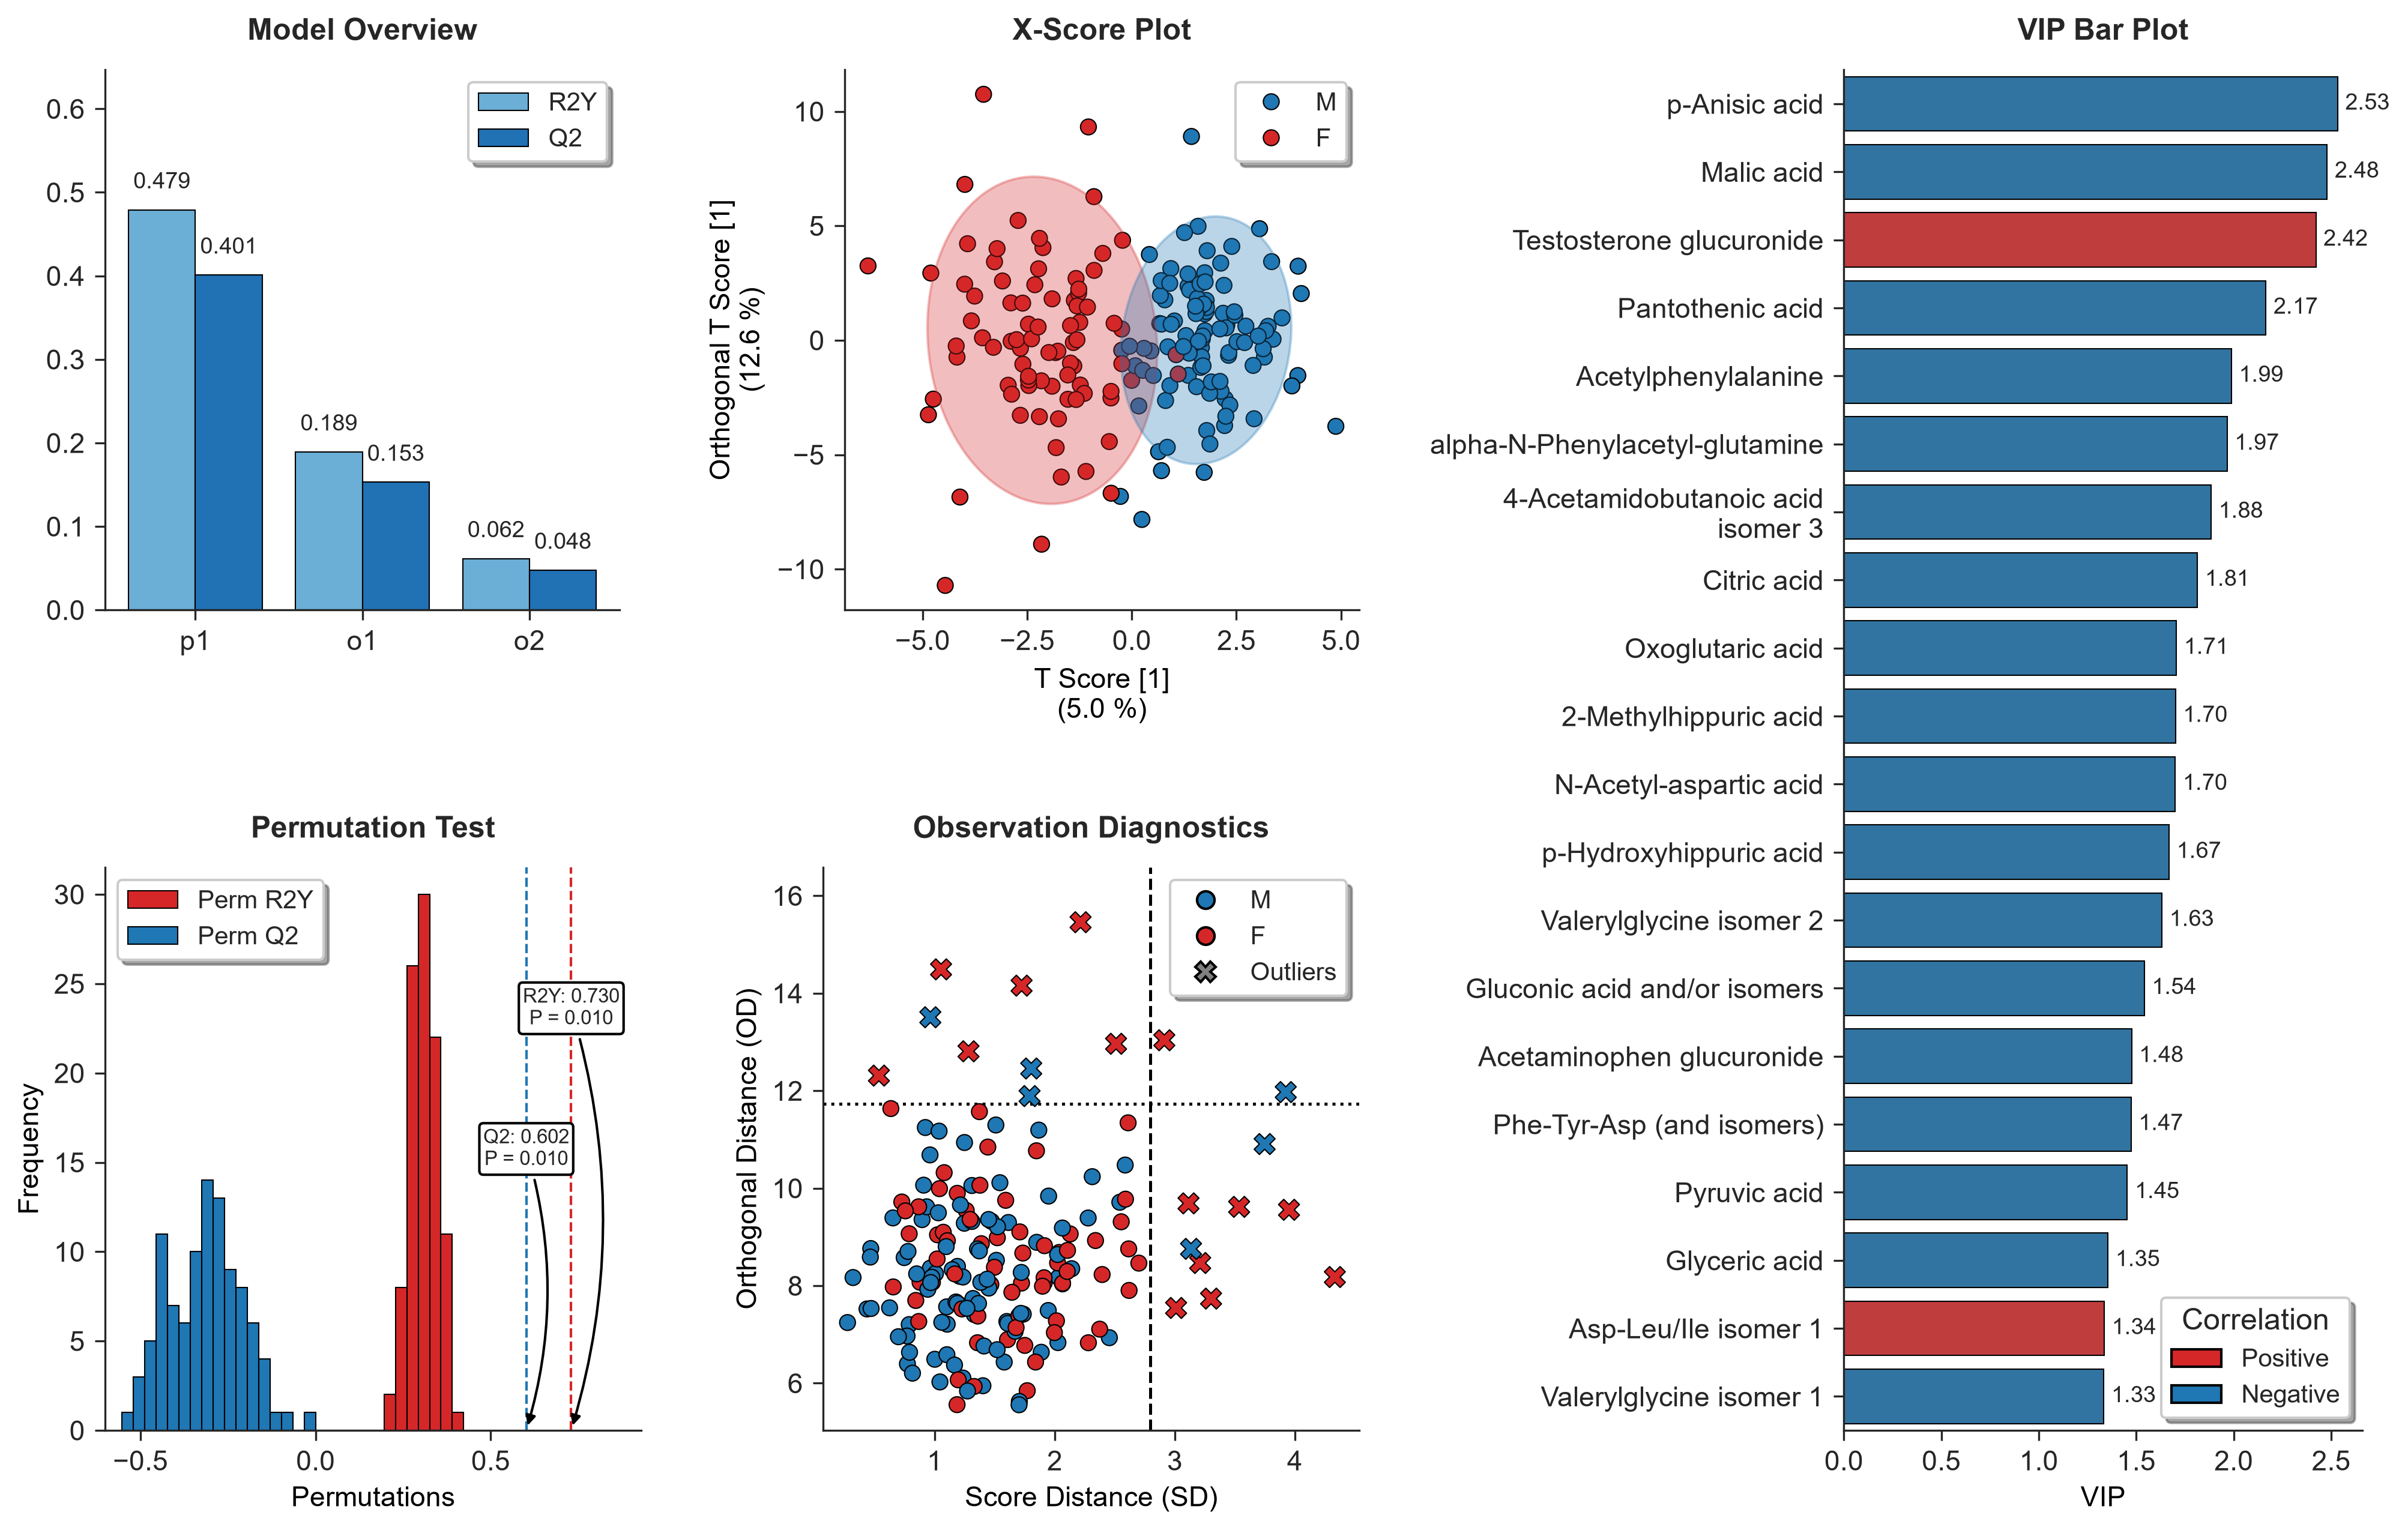

In [7]:
vis = OPLSDA_Visualizer(
    model=model,
    y=y,
    feature_names=df_X.columns,
    sample_names=df_X.index,
    vip_threshold=1.0,
    top_n_vip=20,
)

fig = vis.plot_all(perm_results=perm_results, wrap_width=30, return_fig=True)
fig
